# Genre-Level Analysis of Song Popularity
## Music Streaming Pipeline — Notebook 5 of 5

Throughout the previous four notebooks, a consistent theme emerged: song-level and format-level characteristics are weak predictors of song popularity. Explicitness, release format, and even decade of release all returned negligible or small effect sizes despite producing statistically significant p-values. The one strong signal found in the series was artist popularity, an artist-level variable, which explained 36% of the variance in song popularity in Notebook 2. This raised an obvious follow-up question: if the artist matters more than the song, does the genre the artist operates in also influence how popular their songs become?

This notebook investigates that question by joining the genre data from the pipeline's database, which had not been used in any previous notebook, onto the main dataset. Since artists can belong to multiple genres, I assigned each artist a single primary genre based on their first genre association in the database. After filtering to genres with at least 500 songs to ensure each group was large enough for reliable analysis, I was left with 10 genres: christian, classical, cloud rap, country, k-pop, old school hip hop, pop punk, post-hardcore, r&b, and soundtrack.

Because Levene's test confirmed unequal variances across genres, I used Welch's ANOVA rather than standard one-way ANOVA, followed by a Games-Howell post-hoc test to identify which specific genre pairs were driving the overall result. Both of these methods are the appropriate choices when the equal variance assumption is violated.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene
import pingouin as pg


## LOAD AND MERGE DATA

In [17]:
df = pd.read_csv('../exports/merged_table.csv')
artist_genres = pd.read_csv('../exports/artist_genres.csv')
genres = pd.read_csv('../exports/genres.csv')

In [18]:
ag = artist_genres.merge(genres, on='genre_id', how='inner').groupby('artist_id')['genre_name'].first().reset_index().rename(columns={'genre_name': 'primary_genre'})

In [19]:
df=df.rename({'artist_id_x':'artist_id'}, axis=1)

In [20]:
df

,Unnamed: 0,song_id,song_name,artist_id,album_id,song_listeners,mbid,duration_ms,duration_seconds,duration_minutes,...,created_at_y,artist_popularity,artist_followers,has_genres,album_title,artist_id_y,album_type,album_total_tracks,created_at,updated_at
0,0,5tqPD8ipRNRgVE3E02gxBS,!!!!jealous,1vkWdqcabQ1swciXipkLBj,5UbTuxTQPcYBvhK9pkphmE,1871,b0979956-e40d-4a35-89b1-124af2288354,120280,120,2.00,...,2025-12-30 13:07:49.178087,54.0,380907.0,f,!!!!jealous,1vkWdqcabQ1swciXipkLBj,single,2,2025-12-30 13:07:49.35899,2025-12-30 13:07:49.35899
1,1,07eWLZke8ZCN1RIBziDhr3,!negative,5PmnU0FaFDg8T5VWmPidyy,50PhqXNQr1TJJXHFZ3FLvO,0,NaN,103750,103,1.72,...,2026-01-07 11:37:51.416295,NaN,NaN,f,cathode,5PmnU0FaFDg8T5VWmPidyy,compilation,33,2026-01-07 11:37:51.418937,2026-01-07 11:41:13.65155
2,2,2z0LmeqmAlLsaTG63OwQ5g,!resident evil,2j08aS9NK6tcST4pG1KRXr,03eawc7vQ6zBcWPIPFohVW,0,NaN,122483,122,2.03,...,2026-01-07 18:16:40.404192,NaN,NaN,f,!resident evil,2j08aS9NK6tcST4pG1KRXr,single,3,2026-01-07 18:16:40.415505,2026-01-07 18:16:43.171338
3,3,18g3r7GbyTTvccVYCHULZa,"""...and accordinge as i desired ther cam a let...",0Ty63ceoRnnJKVEYP0VQpk,0gtKu9KQ5TmsatyjgTlBlH,11100,7944ed53-2a58-4035-9b93-140a71e41c34,55720,55,0.92,...,2025-12-30 12:23:42.159808,74.0,3955088.0,t,songs from the labyrinth,0Ty63ceoRnnJKVEYP0VQpk,album,23,2025-12-30 12:23:42.160553,2025-12-30 12:23:42.160553
4,4,4RMK0c30Vl3DGG50wOLpab,"""...and accordinge as i desired ther cam a let...",0Ty63ceoRnnJKVEYP0VQpk,04GSMZ8zc5UwrjlTALc1kI,11100,7944ed53-2a58-4035-9b93-140a71e41c34,55720,55,0.92,...,2025-12-30 12:23:42.159808,74.0,3955088.0,t,songs from the labyrinth - tour edition,0Ty63ceoRnnJKVEYP0VQpk,album,26,2025-12-30 12:23:42.214281,2025-12-30 12:23:42.214281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109286,109286,6nUBIMEFZmm1GRDuskcbLm,천 번 차이는 남자,5fILtblfsRxeAEn72ZLBhx,2MJKsUJBX528r1b3P2yg7T,614,NaN,138559,138,2.30,...,2026-01-07 09:33:15.23123,NaN,NaN,f,쪽집게연애강의서,5fILtblfsRxeAEn72ZLBhx,single,4,2026-01-07 18:16:09.169258,2026-01-07 18:16:10.068242
109287,109287,6HmqWhnp3mAgm8glPBzYVw,파라다이스 (메인 테마),4zYdTQheeWFEGotJyvhYJB,4jMu4ZrYUtiQNHIZvS42oR,0,NaN,265960,265,4.42,...,2025-12-30 12:48:55.333754,NaN,NaN,f,꽃보다 남자 (original television soundtrack),4zYdTQheeWFEGotJyvhYJB,compilation,13,2025-12-30 12:48:55.334745,2025-12-30 13:14:45.022796
109288,109288,14L6wWMb636kbjdjrYmFCC,해결사,0jVvkFPa6YbFXQ3Qmhita0,04Mokiv2E1mI9SIF1AMzob,9541,NaN,222933,222,3.70,...,2026-01-07 13:53:47.628631,43.0,315293.0,t,해결사 - the 1st album,0jVvkFPa6YbFXQ3Qmhita0,album,10,2026-01-07 18:16:42.243807,2026-01-07 18:16:45.258971
109289,109289,2xsndC3jwFMDk45alOgKQU,＋1,0ixzjrK1wkN2zWBXt3VW3W,6ovVqQoICSyT4nry3TX3ru,2227,387bd91c-45c2-4c83-896e-fe4bd1a6907b,241573,241,4.02,...,2025-12-30 13:07:49.244564,69.0,3245642.0,t,カーテンコール,0ixzjrK1wkN2zWBXt3VW3W,single,4,2026-01-07 14:35:40.943239,2026-01-07 14:39:02.450754


In [21]:
df = df.merge(ag, on='artist_id', how='inner')

In [22]:
df.to_csv('../exports/final_data.csv')

In [23]:
df.columns

Index(['Unnamed: 0', 'song_id', 'song_name', 'artist_id', 'album_id',
       'song_listeners', 'mbid', 'duration_ms', 'duration_seconds',
       'duration_minutes', 'engagement_ratio', 'release_date',
       'release_date_precision', 'is_explicit', 'popularity', 'track_number',
       'is_playable', 'created_at_x', 'updated_at_x', 'bpm', 'energy',
       'spectral_centroid', 'zero_crossing_rate', 'danceability',
       'preview_url', 'harmonic_ratio', 'percussive_ratio', 'analysis_date',
       'artist_name', 'on_tour', 'total_listeners', 'total_playcount',
       'plays_per_listener', 'updated_at_y', 'created_at_y',
       'artist_popularity', 'artist_followers', 'has_genres', 'album_title',
       'artist_id_y', 'album_type', 'album_total_tracks', 'created_at',
       'updated_at', 'primary_genre'],
      dtype='object')

In [24]:
df= df[['song_id', 'song_name', 'artist_id', 'popularity', 'primary_genre', 'has_genres', 'bpm', 'energy', 'danceability', 'spectral_centroid', 'zero_crossing_rate', 'percussive_ratio']]

In [25]:
data=df[['song_id', 'primary_genre', 'popularity' ]]
data

,song_id,primary_genre,popularity
0,18g3r7GbyTTvccVYCHULZa,soft rock,9
1,4RMK0c30Vl3DGG50wOLpab,soft rock,1
2,5ets7bYmsqDsc36vA5HWkG,musicals,6
3,5Vgfh5XyxNqcUG1sw9bj7k,country,33
4,0FAvHoLDXDbSMyCJSEyz3i,soundtrack,58
...,...,...,...
37570,3QZeZgeeGlty1sHAxdfQ1w,k-pop,42
37571,668XHwUn7PorVgZHgiBVda,k-ballad,19
37572,14L6wWMb636kbjdjrYmFCC,k-pop,37
37573,2xsndC3jwFMDk45alOgKQU,j-pop,53


## FILTERING AND EXPLORATORY ANALYSIS

In [47]:
def get_genres(df:pd.DataFrame, min_songs: int):
    genre_counts= df['primary_genre'].value_counts()
    valid_genres = genre_counts[genre_counts > min_songs].index
    df = df[df['primary_genre'].isin(valid_genres)]

    print(f"Genres kept: {df['primary_genre'].nunique()}")
    print(f"Rows kept:   {len(df)}")
    print()
    print(df['primary_genre'].value_counts())
    return df

In [48]:
data=get_genres(data, min_songs=500)



Genres kept: 10
Rows kept:   7345

primary_genre
soundtrack            1229
post-hardcore          867
country                855
classical              741
k-pop                  688
cloud rap              654
old school hip hop     642
pop punk               600
r&b                    563
christian              506
Name: count, dtype: int64


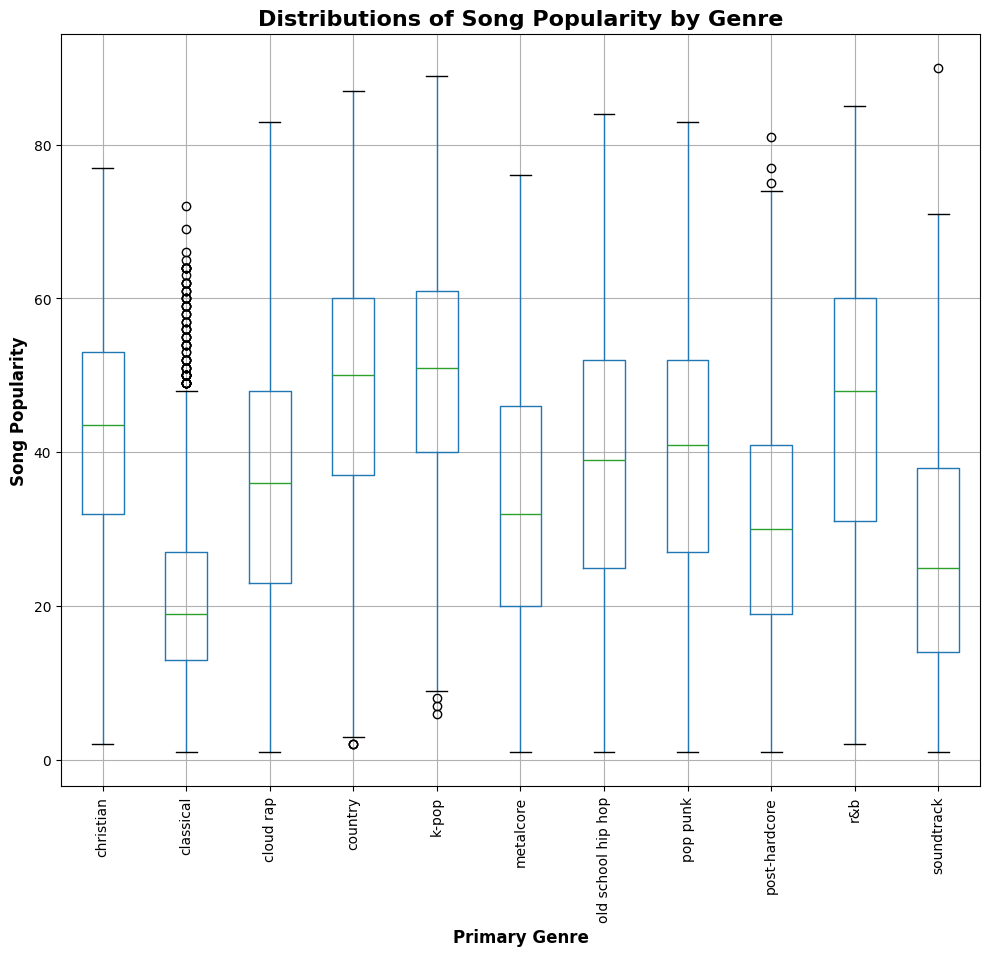

In [29]:

data.boxplot(column ='popularity', by='primary_genre', figsize=(10,10))
plt.title('Distributions of Song Popularity by Genre', fontweight='bold', fontsize=16)
plt.xlabel('Primary Genre', fontsize=12, fontweight='bold')
plt.ylabel('Song Popularity', fontsize=12, fontweight='bold')
plt.xticks(rotation=90)


plt.tight_layout()
plt.suptitle('')
plt.show()

In [32]:
for genre in data['primary_genre'].unique():
    group = data[data['primary_genre']==genre]['popularity']
    print(f'{genre.upper():<25} mean: {group.mean():<8.2f} median: {group.median():<8.2f} mode: {group.mode()[0]:<8}')

COUNTRY                   mean: 47.47    median: 50.00    mode: 51      
SOUNDTRACK                mean: 26.87    median: 25.00    mode: 22      
POST-HARDCORE             mean: 30.36    median: 30.00    mode: 33      
CLOUD RAP                 mean: 35.89    median: 36.00    mode: 46      
R&B                       mean: 45.61    median: 48.00    mode: 50      
OLD SCHOOL HIP HOP        mean: 38.61    median: 39.00    mode: 45      
POP PUNK                  mean: 39.65    median: 41.00    mode: 48      
K-POP                     mean: 50.39    median: 51.00    mode: 57      
CLASSICAL                 mean: 22.03    median: 19.00    mode: 16      
CHRISTIAN                 mean: 42.44    median: 43.50    mode: 40      


In [33]:
print(f"Average Popularity Score for the Dataset: {data['popularity'].mean():.2f}")

Average Popularity Score for the Dataset: 36.78


There is quite a spread within the distributions of the genre-grouped data. What immediately sticks out to me is that K-POP has a mean popularity score of 50.39, much higher than the average song popularity score for the entire dataset (36.78). Some other genres that follow this trend are R&B (45.61) and country music (47.47). A possible reason for these genres being rated higher on average could be their mainstream success as genres. In recent years K-POP has gotten a more global audience, an audience that really resonates with the music being produced. Additionally, country and R&B music have been cult classic music genres for decades, possibly driving their average song popularity. On the other hand, genres like classical (22.03) music, soundtrack (26.87), and post-hardcore (30.36) music fall far below the sample average. An explanation for their low rankings could be that these genres don't resonate with a lot of people. While classical music has been around for centuries, classical music isn't going viral, rather it exists in its own space. Soundtrack music is made for films, TV, or video games. While some of the songs might become viral hits like Skyfall by Adele, their primary purpose might be to create an ambiance in a film rather than to garner mainstream success, resulting in their low avg popularity score. Post-Hardcore is a very specific genre often charactetrized by an intense, emotional sound that often doesn't resonate with the mainstream audiance. Rather this genre has a smaller cult following that enjoys this type of music. All-in-all, there is high variance between the different genre groups, making this perfect for an ANOVA test to see if genre is a good predictor of song popularity.

In [34]:
data['primary_genre'].unique()

array(['country', 'soundtrack', 'post-hardcore', 'cloud rap', 'r&b',
       'old school hip hop', 'pop punk', 'k-pop', 'classical',
       'christian'], dtype=object)

In [35]:
country = data[data['primary_genre']=='country']['popularity']
soundtrack = data[data['primary_genre']=='soundtrack']['popularity']
post_hardcore = data[data['primary_genre']=='post-hardcore']['popularity']
cloud_rap = data[data['primary_genre']=='cloud rap']['popularity']
rnb = data[data['primary_genre']=='r&b']['popularity']
hip_hop = data[data['primary_genre']=='old school hip hop']['popularity']
pop_punk = data[data['primary_genre']=='pop punk']['popularity']
kpop = data[data['primary_genre']=='k-pop']['popularity']
classical = data[data['primary_genre']=='classical']['popularity']
christian = data[data['primary_genre']=='christian']['popularity']


## VARIANCE CHECK — LEVENE'S TEST

In [36]:
stat, p_val = levene(country, soundtrack, post_hardcore, cloud_rap, rnb, hip_hop, pop_punk, kpop, classical, christian)
print(f"P-VALUE: {p_val:.8f}")

P-VALUE: 0.00000000


The levene test returned a p-value of 0.00 meaning that we can reject the null hypothesis. In the context of this test it communicates to me that the variance between the groups of data is significantly different. This is corroborated by the distributions and the measures of central tendency that show wildly different distributions. Since my data fails the assumption that the variance between groups is equal/similar, I will use a Welch's ANOVA test which does not assume equal variances amongst the groups.

## WELCH'S ANOVA

In [37]:
results = pg.welch_anova(data=data, dv='popularity', between='primary_genre')
print(results)

          Source  ddof1        ddof2           F  p_unc       np2
0  primary_genre      9  2773.277885  271.391526    0.0  0.236716


## RESULTS:

* DDOF1 = 9: This represents the degrees of freedom which is calculated by taking n groups - 1. This confirms that we were working with 10 genres (10-1=9).
* F = 271.39: This is the F statistic which represents the amount of variance between groups compared to the variance within the groups. This means that the variance between each group is 271x bigger than the variance within the grou;s. This shows that the genre groups vary greatly and are different from one another.
* p_unc = 0.0: This represents that we should reject the null hypothesis and accept that the mean popularity amongst the groups are significantly different.
* np2 = .236: This value is the partial-eta-squared or effect size. With a value of .236 it translates to genre explaining roughly 23.6% of the variance in the target variable (popularity). This is the highest value I have observed so far. 

## GAMES-HOWELL POST-HOC TEST

In [38]:
posthoc = pg.pairwise_gameshowell(data=data, dv='popularity', between='primary_genre')
print(posthoc)

                     A                   B     mean_A     mean_B       diff  \
0            christian           classical  42.442688  22.026991  20.415697   
1            christian           cloud rap  42.442688  35.892966   6.549721   
2            christian             country  42.442688  47.467836  -5.025149   
3            christian               k-pop  42.442688  50.393895  -7.951208   
4            christian  old school hip hop  42.442688  38.612150   3.830538   
5            christian            pop punk  42.442688  39.646667   2.796021   
6            christian       post-hardcore  42.442688  30.359862  12.082826   
7            christian                 r&b  42.442688  45.612789  -3.170101   
8            christian          soundtrack  42.442688  26.870627  15.572061   
9            classical           cloud rap  22.026991  35.892966 -13.865976   
10           classical             country  22.026991  47.467836 -25.440846   
11           classical               k-pop  22.02699

The Games-Howell post-hoc test reveals clear and meaningful differences in song popularity across genres, with classical sitting at the bottom of the rankings (mean = 22.03) and k-pop sitting at the top (mean = 50.39). Classical scores significantly lower than every other genre in the dataset and produces the largest effect sizes in the entire table — the classical vs k-pop comparison has a Hedges g of -1.86, the classical vs country comparison sits at -1.58, and classical vs r&b at -1.42. These are all large effects, meaning the gaps are not just statistically real but large enough to be genuinely meaningful in practice.

K-pop is the strongest performing genre and its advantage over the bottom of the table is substantial. The k-pop vs soundtrack difference produces a Hedges g of 1.52 and the k-pop vs classical gap is the most extreme pair in the entire analysis. Country and r&b, despite differing in mean by about 1.9 points, are statistically indistinguishable from each other (p = 0.650, g = 0.11) and together form the second tier of the rankings. Similarly, old school hip hop and pop punk are effectively the same group (p = 0.992, g = -0.06), and cloud rap does not differ significantly from either of them, meaning these three genres occupy a middle cluster that performs consistently but unremarkably.

 Soundtrack consistently underperforms across nearly every comparison, reinforcing the earlier observation that it functions more as a release category than a true genre, and pulls in large volumes of niche orchestral content that scores very low on popularity.

Taken together, the genre analysis produced the most practically meaningful findings of the entire notebook series. The large effect sizes seen here stand in sharp contrast to the negligible effects found in Notebook 3, where explicit content and release format explained almost none of the variance in popularity. Genre, by comparison, is a variable worth taking seriously as a predictor of song performance.

# Conclusion

This notebook set out to answer whether music genre is a meaningful predictor of song popularity, a question motivated by the consistent finding across Notebooks 1 through 4 that song-level variables like explicitness, release format, and audio features explained very little of the variance in popularity scores.

The answer is yes, and by a significant margin compared to anything tested previously. The Welch's ANOVA returned an F-statistic of 271 and a partial eta-squared of 0.237, meaning genre accounts for approximately 23.7% of the variance in song popularity. To put that in context, the strongest result from the entire previous series was artist popularity explaining 36% of variance in Notebook 2, and the next best was decade of release at just 1.3% in Notebook 4. Genre sits firmly in between those two, and unlike decade of release, its effect is not easily explained away by algorithmic bias, it reflects genuine differences in how audiences engage with different styles of music.

The Games-Howell post-hoc test gave us a detailed picture of where those differences lie. K-pop sits at the top of the rankings with a mean popularity of 50.4, followed by country (47.5) and r&b (45.6). Classical sits at the bottom with a mean of 22.0, scoring significantly lower than every other genre and producing the largest effect sizes in the table, the classical vs k-pop gap has a Hedges g of -1.86, which is a large effect by any standard. Several genre pairs were statistically indistinguishable from each other: country and r&b, old school hip hop and pop punk, and cloud rap with both of those. This suggests the 10 genres naturally cluster into roughly four tiers rather than 10 distinct levels.

Taking a step back across all five notebooks, the clearest conclusion is that who makes a song matters far more than what the song sounds like or how it is packaged. Artist popularity explained 36% of variance, genre explained 23.7%, and everything else, explicitness, format, tempo, energy, explained almost nothing. For any team making decisions about catalogue investment, playlist curation, or artist development, the data consistently points in the same direction: back to the artist.

In [40]:
audio = df[['primary_genre', 'bpm', 'energy', 'spectral_centroid', 'zero_crossing_rate', 'danceability', 'percussive_ratio']]

In [41]:
audio.sample(10)

,primary_genre,bpm,energy,spectral_centroid,zero_crossing_rate,danceability,percussive_ratio
9367,trap,135.999,0.22912,2580.272,0.09642,0.33784,0.27459
13607,horrorcore,123.047,0.20773,2463.442,0.09296,0.30703,0.37542
17651,pop,135.999,0.29540,2217.482,0.07714,0.36713,0.16449
27172,christian,112.347,0.25933,3106.294,0.15156,0.32850,0.31152
29556,french indie pop,69.837,0.19612,1754.092,0.06826,0.21647,0.28863
37469,cantopop,129.199,0.23994,2287.493,0.08902,0.33157,0.24774
14197,emo,161.499,0.25745,2804.191,0.13689,0.39835,0.36146
28715,classic country,161.499,0.21847,2314.939,0.11199,0.37388,0.32492
20285,east coast hip hop,92.285,0.24156,2298.067,0.11011,0.28123,0.46618
8087,soundtrack,172.266,0.12145,750.784,0.04891,0.32891,0.10799


In [ ]:
audio = get_genres(audio, min_songs=500)

Genres kept: 10
Rows kept:   7345

primary_genre
soundtrack            1229
post-hardcore          867
country                855
classical              741
k-pop                  688
cloud rap              654
old school hip hop     642
pop punk               600
r&b                    563
christian              506
Name: count, dtype: int64


In [52]:
audio.groupby('primary_genre')[['bpm', 'energy', 'danceability', 'spectral_centroid', 'zero_crossing_rate', 'percussive_ratio']].mean()

,bpm,energy,danceability,spectral_centroid,zero_crossing_rate,percussive_ratio
primary_genre,,,,,,
christian,122.572731,0.226021,0.317084,2364.852680,0.101070,0.291022
classical,124.833082,0.090286,0.245430,1222.300749,0.070973,0.161958
cloud rap,125.908968,0.265737,0.337843,2458.270810,0.080556,0.245395
country,122.995265,0.231058,0.320475,2296.388069,0.102269,0.311145
k-pop,120.015020,0.274268,0.339639,2691.368417,0.112412,0.332062
old school hip hop,110.781907,0.219935,0.297397,2511.687749,0.106280,0.398049
pop punk,117.753617,0.256425,0.330670,2634.868135,0.129137,0.340060
post-hardcore,122.470512,0.252672,0.336447,2649.768106,0.132027,0.348995
r&b,116.757874,0.222024,0.304778,2401.961860,0.093353,0.314435


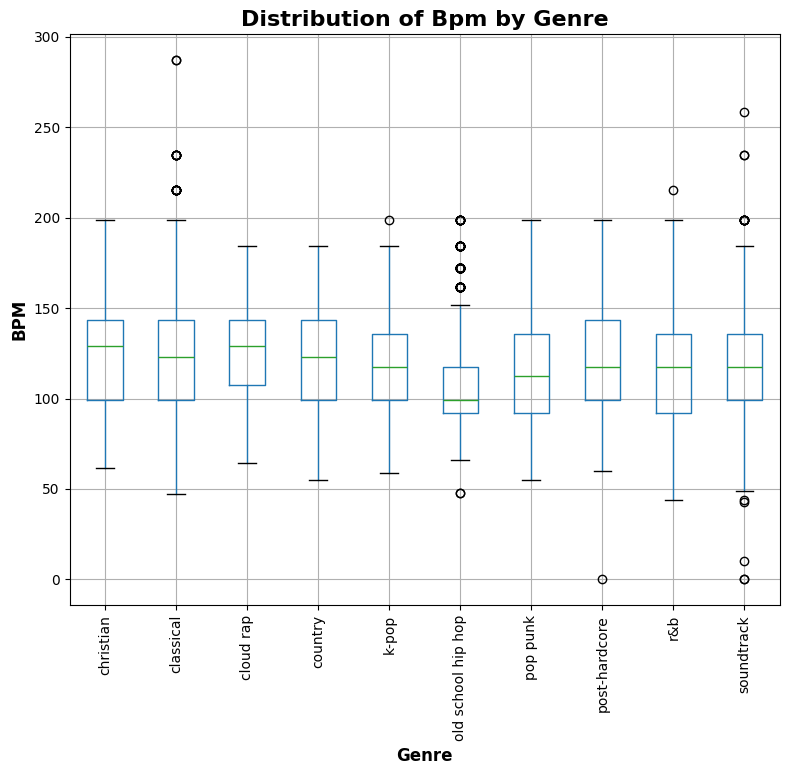

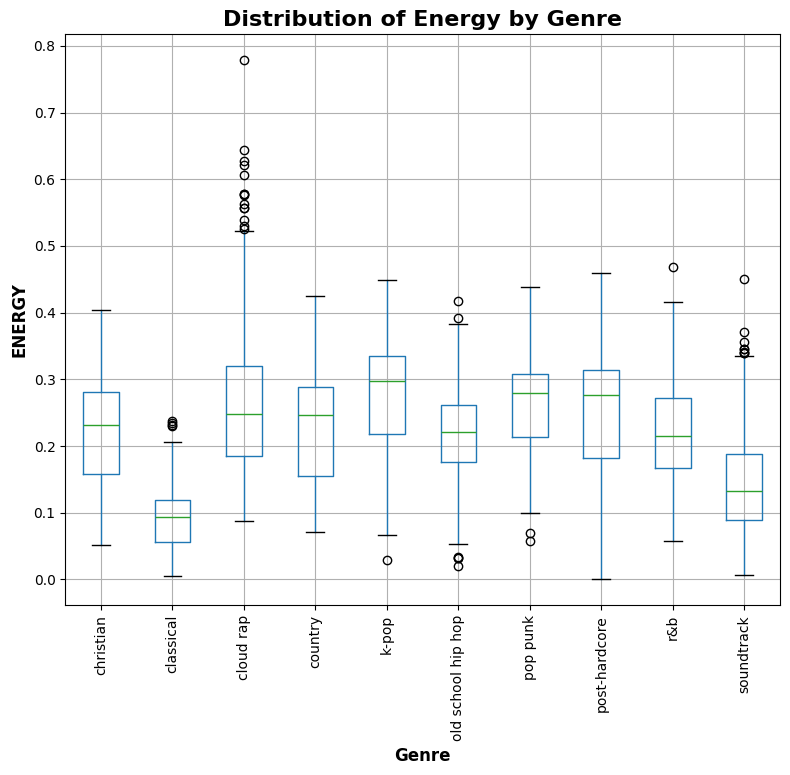

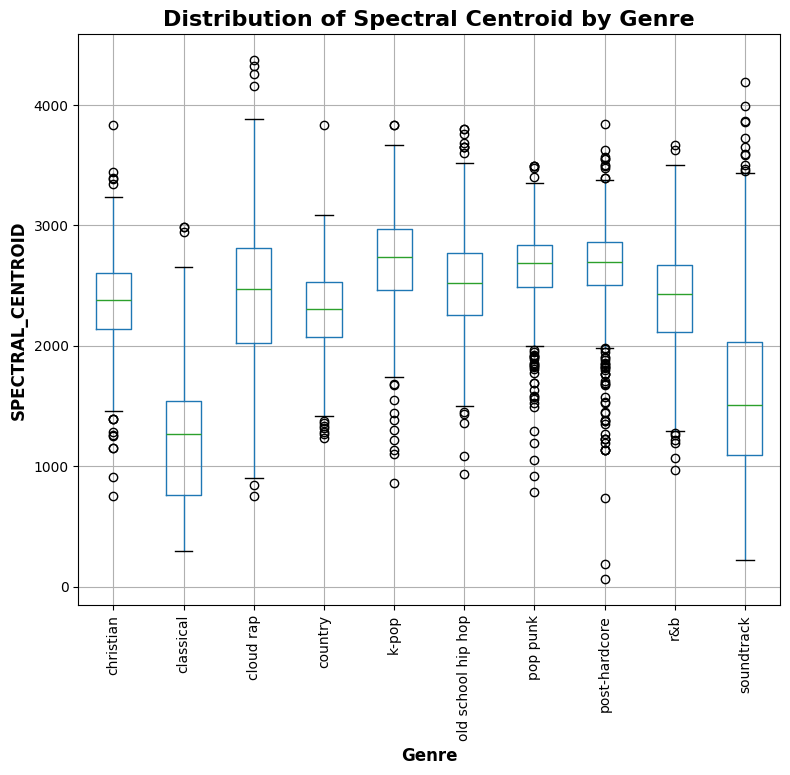

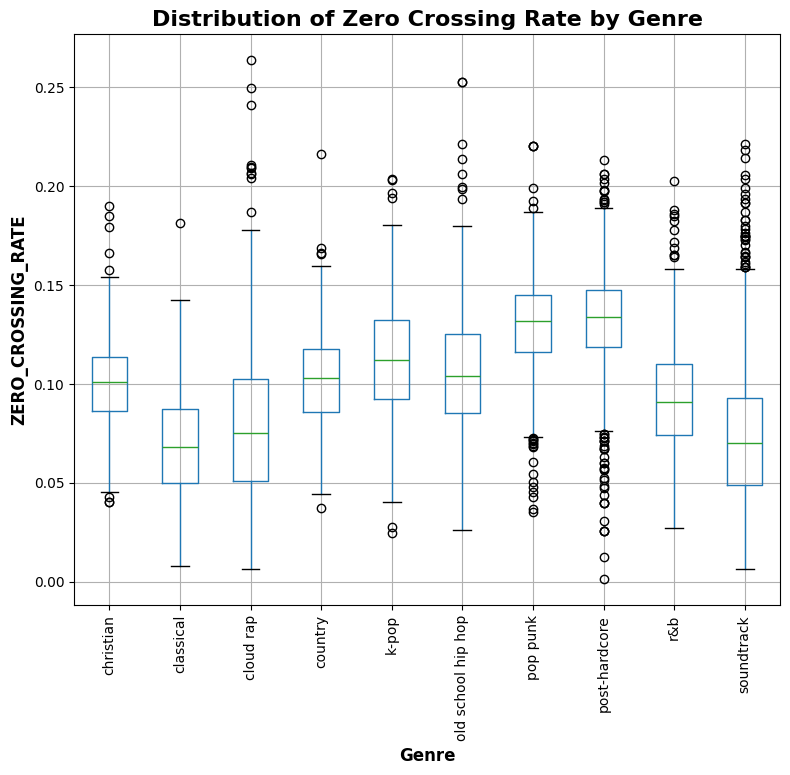

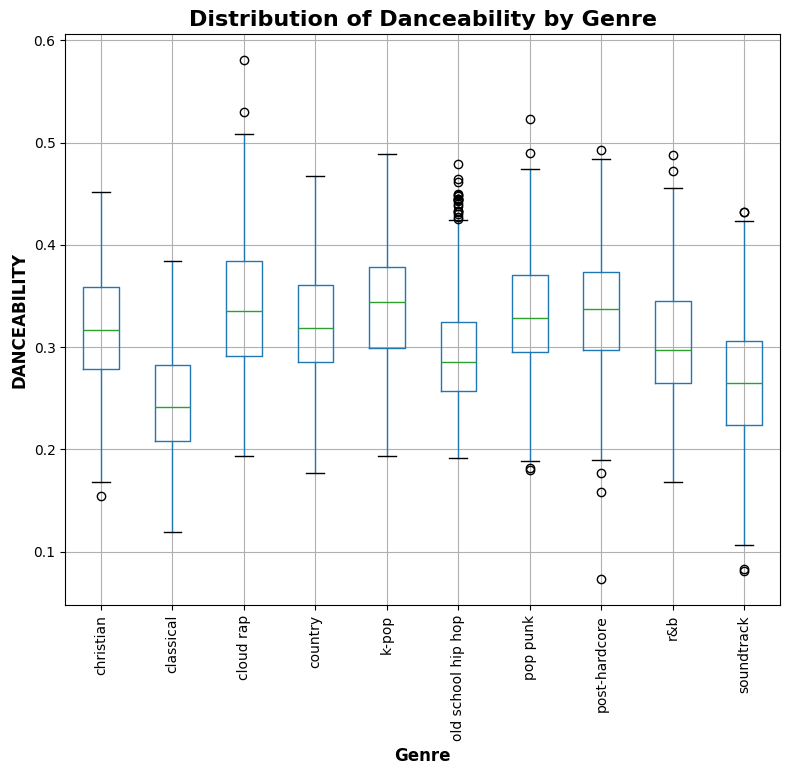

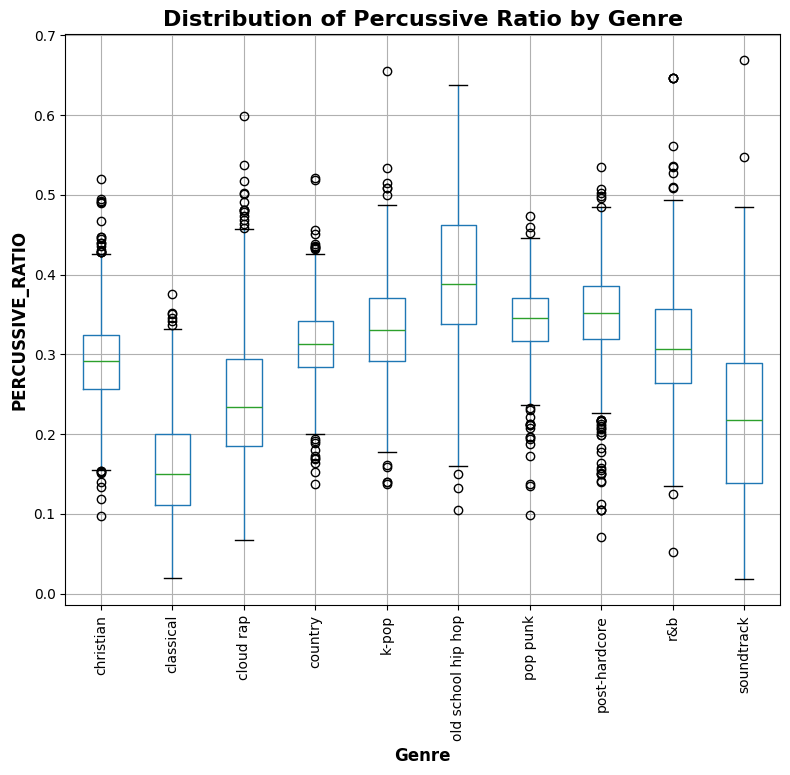

In [67]:
for idx, column in enumerate(audio.columns[1:]):
    audio.boxplot(column=column, by='primary_genre', figsize=(8,8))
    plt.title(f'Distribution of {column.title().replace('_', ' ')} by Genre', fontsize=16, fontweight='bold')
    plt.ylabel(f'{column.upper()}', fontsize=12, fontweight='bold')
    plt.xlabel(f'Genre', fontsize=12, fontweight='bold')
    plt.xticks(rotation=90)
    plt.suptitle('')
    plt.tight_layout()

